# Cartopy — Mapas y proyecciones cartográficas

## Geocomputación (1GEO20) — PUCP, 2026-II — Semana 4

Este notebook cubre los fundamentos de Cartopy para crear mapas con proyecciones cartográficas, y su aplicación a datos sintéticos y ráster reales (.tif) .

**Nota sobre el entorno:**
- Si trabajas en **Google Colab**, instala Cartopy antes de continuar (ver celda siguiente).
- Si trabajas en tu **computadora local**, asegúrate de tener seleccionado el environment del curso (`1geo20`); las librerías necesarias ya  están instaladas ahí.

**Cómo usar este notebook:** completa las celdas marcadas como Ejercicio. Ejecuta cada celda con `Shift + Enter`.

---

In [2]:
# Descomenta las siguientes líneas solo si estás en Google Colab
# !pip install cartopy -q
# No estoy en colab lesgo

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [5]:
### 
import warnings

# Cartopy muestra advertencias (warnings) la primera vez que descarga
# los shapefiles de Natural Earth (costas, fronteras, etc.). No indican
# ningún error, solo información del proceso de descarga, así que las
# desactivamos para no llenar la salida de la celda con texto innecesario.

warnings.filterwarnings('ignore')

# Parte 1 — Fundamentos de Cartopy (sin datos)

## 1. Un mapa por defecto

Cartopy convierte un `Axes` normal de Matplotlib en un `GeoAxes`, indicando una proyección con el parámetro `projection`. 

Ejemplo con la proyección: `PlateCarree` (coordenadas lon/lat sin distorsión, cada punto espaciado uniformemente en grados).

Text(0.5, 1.0, 'Mapa base')

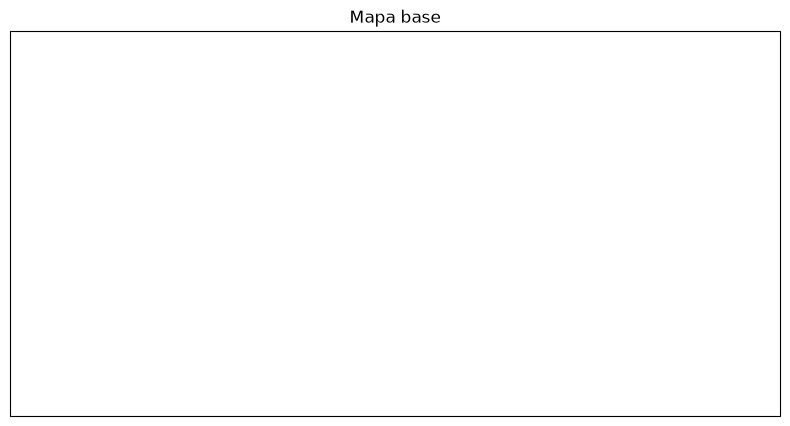

In [6]:
# fig: Marco que encierra los gráficos (como hoja en blanco) | figsize=(x,y): Extensión de largo y alto respectivamente
# ax: Gráfico dentro del marco (puede ser más de uno) | subplot_kw={'projection: ccrs.x()}: Atributo que define la proyección del mapa (ej, mercator)
# PlateCarree: Proyección cilíndrica equidistante. Los meridianos y paralelos forman cuadrados perfectos
# El comando 'plt.subplots' actúa definiendo dos variables (fig, ax) 
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={'projection': ccrs.PlateCarree()})

# Se define el título del gráfico con el comando '.set_title('x')' atribuído a la variable 'ax'. Todas las modificaciones al mapa se realizan por medio de atributos al gráfico 'ax'
ax.set_title('Mapa base')

`figsize` controla el tamaño de la figura.   Prueba cambiar el `figsize` de la celda anterior y correr de nuevo.

## 2. Agregar costas

El método `coastlines()` agrega las líneas de costa, usando datos de Natural Earth (se descargan automáticamente la primera vez que se usan, así que la primera ejecución puede tardar unos segundos).

Text(0.5, 1.0, 'Con costas')

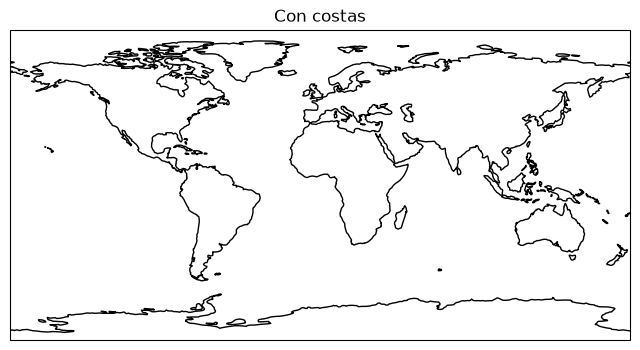

In [7]:
# Natural Earth: Dataset de mapas de dominio público
fig, ax = plt.subplots(figsize=(8, 5), subplot_kw={'projection': ccrs.PlateCarree()})
ax.coastlines()
ax.set_title('Con costas')

## 3. Gridlines

`gridlines()` agrega líneas de referencia de longitud/latitud, y con `draw_labels=True` también los valores en los ejes.

**Nota:** `draw_labels=True` es estable en proyecciones rectangulares como `PlateCarree` o `Mercator`.

Text(0.5, 1.0, 'Con gridlines')

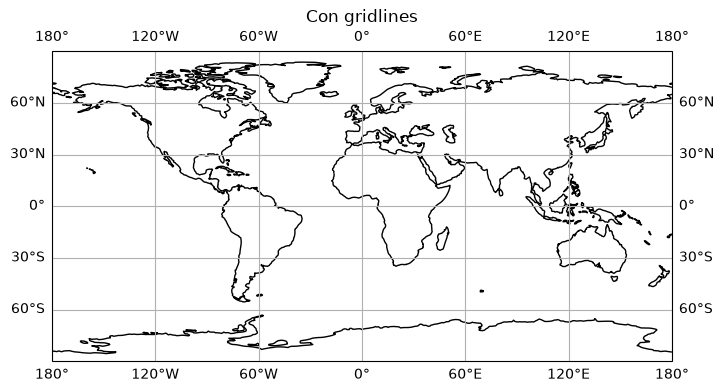

In [8]:
fig, ax = plt.subplots(figsize=(8, 5), subplot_kw={'projection': ccrs.PlateCarree()})
ax.coastlines()

# 'draw_labels=True' permite visualizar los valores de los ejes 
ax.gridlines(draw_labels=True)
ax.set_title('Con gridlines')

# Las modificaciones de linea (en grillas, línea de costa, etc.) incluyen el cambio el color y diseño con los atributos 'color='red'' y 'linestyle='--'', respectivamente

### Ejercicio 1

1. Crea un mapa con proyección `PlateCarree`.
2. Agrega gridlines, cambia el color a rojo y el estilo de línea a punteado.
3. Agrega costas, cambia su color a azul.

Pista: cambia los argumentos `color` y `linestyle` de `gridlines()`, y `color` de `coastlines()`

Text(0.5, 1.0, 'Ejercicio 1')

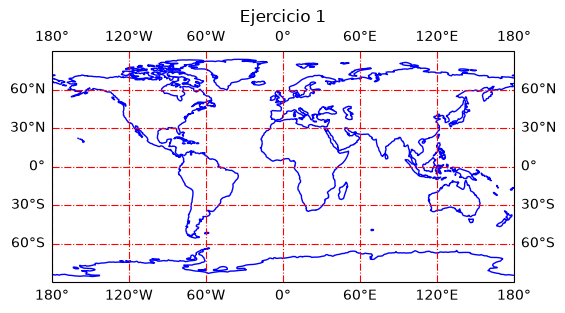

In [9]:
# 1.
fig, ax = plt.subplots(figsize=(8,3), subplot_kw={'projection': ccrs.PlateCarree()})
# 2.
ax.gridlines(color='red', linestyle='-.', draw_labels=True)
# 3.
ax.coastlines(color='blue')

ax.set_title('Ejercicio 1')

## 4. Elegir una región: `set_extent`

Por defecto, `PlateCarree` muestra el mapa completo. `set_extent([lon_min, lon_max, lat_min, lat_max])` recorta a una región específica. Usemos como ejemplo Sudamérica completa.

Text(0.5, 1.0, 'Sudamérica')

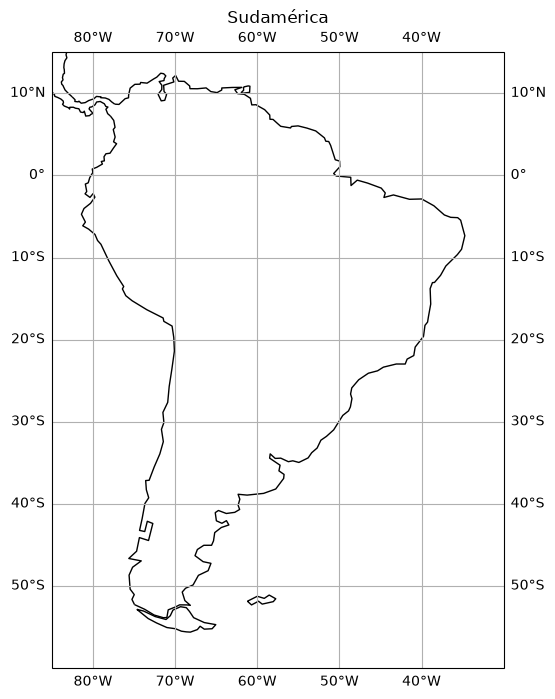

In [10]:
fig, ax = plt.subplots(figsize=(6, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.coastlines()
ax.gridlines(draw_labels=True)

# El comando 'ax.set_extent()' determina la extensión de la figura basada en la projección que se le asigna al mismo comando. La proyección del "recorte" no necesariamente tiene que coincidir con la proyección del gráfico 'ax'
ax.set_extent([-85, -30, -60, 15], crs=ccrs.PlateCarree())

ax.set_title('Sudamérica')

**Nota:** el parámetro `crs=` en `set_extent` indica en qué sistema están los valores que le diste (en este caso, grados lon/lat simples), independientemente de la proyección con la que se muestre el mapa.

### Ejercicio 2

Elige tu propia sub-región dentro de Sudamérica (por ejemplo: un país, una cuenca, una cordillera) y haz zoom con `set_extent`. Agrega gridlines y costas.

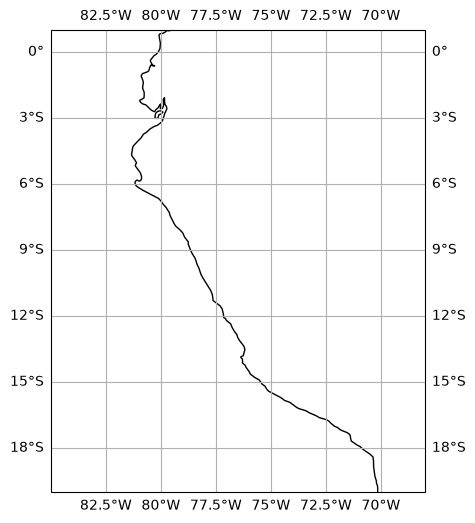

In [11]:
# tu sub-región aquí
fig, ax = plt.subplots(figsize=(5,6), subplot_kw={'projection': ccrs.PlateCarree()})
ax.coastlines()
ax.set_extent([-85, -68, -20, 1], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True)

## 5. Comparar proyecciones

Podemos crear varios `GeoAxes`, cada uno con una proyección distinta, dentro de la misma figura, usando `fig.add_subplot()` en vez de `plt.subplots()`.

Text(0.5, 1.0, 'Lambert Conformal')

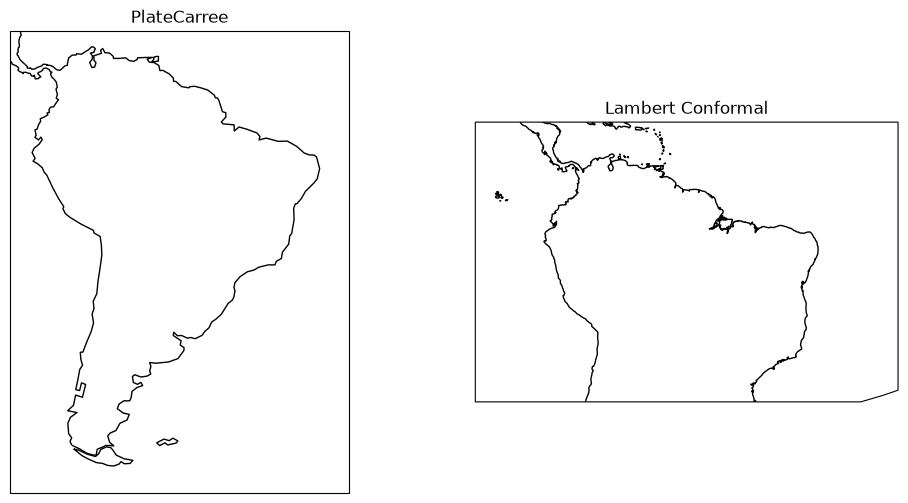

In [12]:
# plt.subplots() puede trabajar con varios gráficos a la vez. Alternativamente, se puede definir la figura de forma indivual (hoja en blanco) con plt.figure() e ir agregando mapas (gráficos)
fig = plt.figure(figsize=(12, 6))

# Los primeros elementos dentro del comando fig.add_subplot(x, y, z,...) indican la posición (fila, columna) y número de gráfico que se está agregando a la figura. Además, la proyección se define en el gráfico, no a la figura.
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax1.coastlines()
ax1.set_extent([-85, -30, -60, 15], crs=ccrs.PlateCarree())
ax1.set_title('PlateCarree')

# LambertConformal es una proyección cónica. El atributo 'central_longitude=-60, central_latitude=-15' obliga a la proyección a orientarse en base a una longitud y latitud específica.
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.LambertConformal(central_longitude=-60, central_latitude=-15))
ax2.coastlines()
ax2.set_extent([-85, -30, -60, 15], crs=ccrs.PlateCarree())
ax2.set_title('Lambert Conformal')

Cada `Axes` puede tener su propia proyección; lo único que se mantiene igual es el `crs=` en `set_extent`, porque los valores de longitud/latitud que le diste siguen siendo los mismos sin importar cómo se vea el mapa después.

### Ejercicio 3

Agrega un tercer subplot con la proyección `Mercator`, usando la misma sub-región que elegiste en el Ejercicio 2.

Text(0.5, 1.0, 'Mercator')

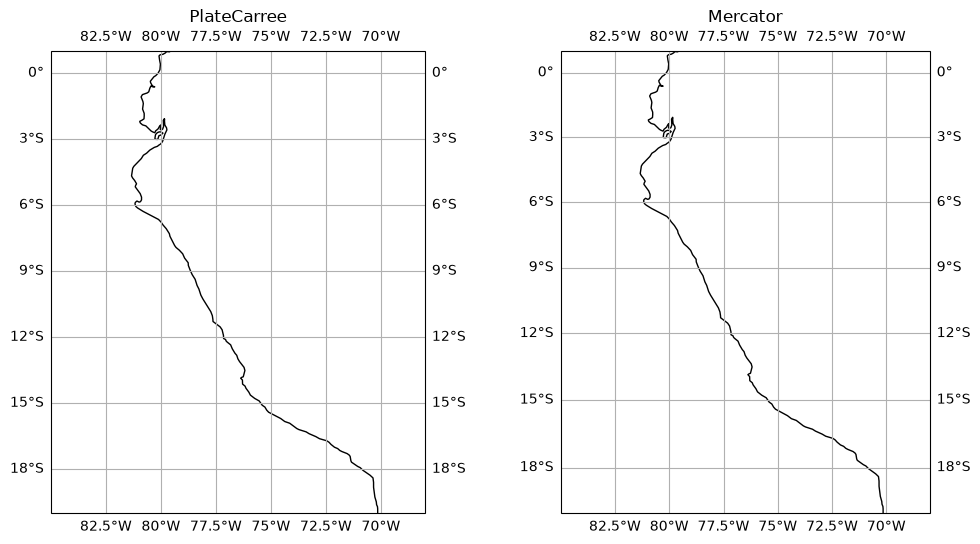

In [13]:
# tu tercer subplot aquí
fig = plt.figure(figsize=(12,6))

ax1 = fig.add_subplot(1,2,1, projection=ccrs.PlateCarree())
ax1.coastlines()
ax1.set_extent([-85, -68, -20, 1], crs=ccrs.PlateCarree())
ax1.gridlines(draw_labels=True)
ax1.set_title('PlateCarree')

ax2 = fig.add_subplot(1,2,2, projection=ccrs.Mercator())
ax2.coastlines()
ax2.set_extent([-85, -68, -20, 1], crs=ccrs.PlateCarree())
ax2.gridlines(draw_labels=True)
ax2.set_title('Mercator')

## 6. Elementos geográficos (features)

Además de `coastlines()`, Cartopy tiene atajos predefinidos en `cfeature` para otros elementos: `LAND`, `OCEAN`, `BORDERS`, `LAKES`, `RIVERS`, `STATES`. Se agregan con `add_feature()`.

Text(0.5, 1.0, 'Sudamérica con features')

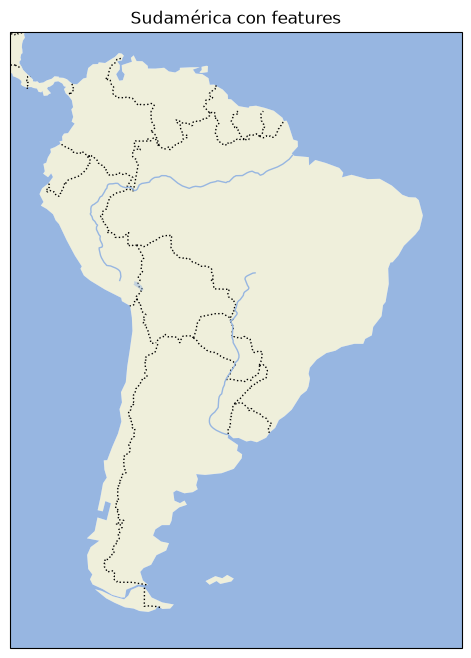

In [14]:
fig, ax = plt.subplots(figsize=(6, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-85, -30, -60, 15], crs=ccrs.PlateCarree())

# ax.add_feature(c.feature.x) permite agregar subelementos provenientes del Natural Earth (ej. ríos, bordes políticos, etc.)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)

# 'cfeature.BORDERS.with_scale('x')' con x = 10m, 50m, o 110m; define la resolución del elemento. Mientras más pequeña es el área mostrada en el gráfico, mayor se quiere la resolución de los elementos
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linestyle=':')

# 'alpha' define el grado de opacidad del elemento al que se le aplica, el rango varía entre 0-1
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.RIVERS)

ax.set_title('Sudamérica con features')

Nota: como con `coastlines()`, la resolución de estos features depende del área mostrada. Para más detalle, se puede indicar la escala explícitamente: `cfeature.BORDERS.with_scale('50m')`.

### Ejercicio 4

Sobre tu mapa del Ejercicio 2 (tu sub-región), agrega `LAND`, `OCEAN`, `BORDERS` y `RIVERS`. Prueba cambiar los colores con `facecolor=`/`edgecolor=`.

Text(0.5, 1.0, 'Perú con features')

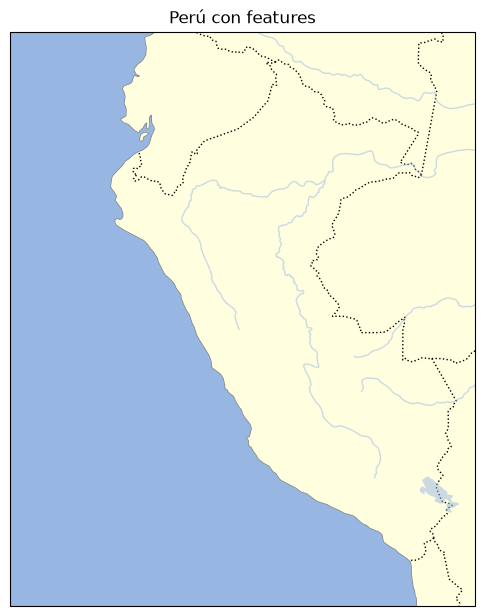

In [15]:
# tu mapa con features aquí
fig, ax = plt.subplots(figsize=(6, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-85, -68, -20, 1], crs=ccrs.PlateCarree())

# Los atributos 'facecolor='x'' y 'edgecolor='y'' modifican el color del relleno y borde respectivamente del elemento al que se le atribuye
ax.add_feature(cfeature.LAND, facecolor='lightyellow', edgecolor='gray')
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linestyle=':')
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.RIVERS, alpha=0.5)

ax.set_title('Perú con features')

## 7. Otros shapefiles: menor resolución y shapefiles propios

Los features que ya vimos (`cfeature.LAND`, etc.) usan por defecto shapefiles de alta resolución de Natural Earth. Para mapas grandes (como todo Sudamérica), a veces conviene usar una resolución menor, lo que acelera bastante el renderizado.

Text(0.5, 1.0, 'Sudamérica, resolución baja (110m)')

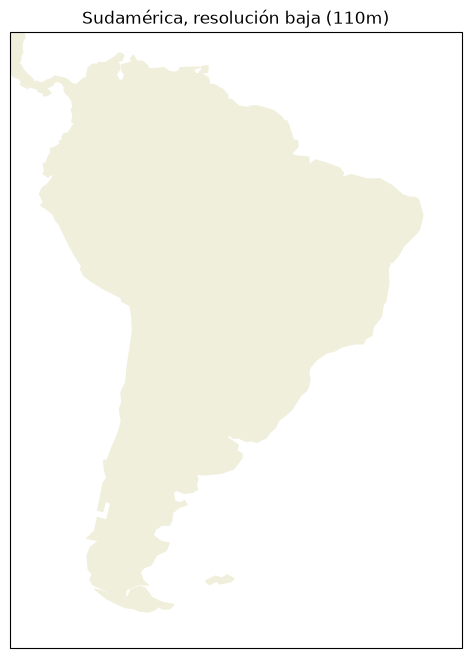

In [16]:
# El comando 'cfeature.NaturalEarthFeature('x', 'y',...)' permite asignar el dataset deseado a una variable. El atributo 'x' hace referencia a la categoría del dataset (ej. physical, cultural, etc.) y 'y' indica el nombre del dataset (ej. ocean; en minúscula). Estos atributos permiten localizar el feature deseado de la base de datos de Natural Earth. La escala define la resolución de datos, un mayor valor indica menor resolución.
# edgecolor='face' asigna el color definido en el atributo 'facecolor='x''. 'facecolor=cfeature.COLORS['land']' llama el código del color asignado al elemento 'land' dentro del registro de features del dataset. Asignar colores por este método permite usar coloraciones estandarizadas.
land_low_res = cfeature.NaturalEarthFeature(
    'physical', 'land', scale='110m',
    edgecolor='face', facecolor=cfeature.COLORS['land']
)

fig, ax = plt.subplots(figsize=(6, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-85, -30, -60, 15], crs=ccrs.PlateCarree())
ax.add_feature(land_low_res) # Con el feature definido en una variable, solo se la llama en el comando '.add_feature()'
ax.set_title('Sudamérica, resolución baja (110m)')

También es posible usar un shapefile propio (por ejemplo, uno con límites administrativos del Perú) en vez de depender solo de Natural Earth, con `cartopy.io.shapereader`:

```python
import cartopy.io.shapereader as shpreader

shp_path = 'ruta/a/tu/archivo.shp'
geometrias = list(shpreader.Reader(shp_path).geometries())

ax.add_geometries(geometrias, crs=ccrs.PlateCarree(), edgecolor='black', facecolor='none')
```

No hay ejercicio para esta sección — es solo referencia para cuando necesiten cargar un límite administrativo específico más adelante en el curso.

# Parte 2 — Datos reales y sintéticos

## 8. `projection` vs `transform`

Cuando graficamos datos sobre un mapa, hay dos sistemas de coordenadas en juego: cómo se **muestra** el mapa (`projection`) y en qué sistema **están** los datos originales (`transform`). Veamos qué pasa si los confundimos.

Primero, generamos un dato sintético secuencial (por ejemplo, una "temperatura" ficticia) sobre una grilla lon/lat de Sudamérica.

In [17]:
lon = np.linspace(-85, -30, 100) # Longitud: Eje x
lat = np.linspace(-60, 15, 100) # Latitud: Eje y
# 'np.meshgrid(x,y)' recibe arrays de una dimensión y devuelve una tupla de coordenadas con los datos recibidos. 
lon2d, lat2d = np.meshgrid(lon, lat)

# Dato sintético secuencial (ej. "temperatura"). 'np.sin()' trabaja con grados sexagesimales, el atributo 'np.deg2rad(x)' convierte los datos de 'x' en radianes.
temperatura_sintetica = 30 - 0.3 * np.abs(lat2d) + 2 * np.sin(np.deg2rad(lon2d))
# Los datos de temperatura se encuentran asignados a coordenadas simples, no geográficas.

Ahora lo graficamos en una proyección distinta a PlateCarree (Mercator), **sin** indicar `transform`:

Text(0.5, 1.0, 'Sin transform (incorrecto)')

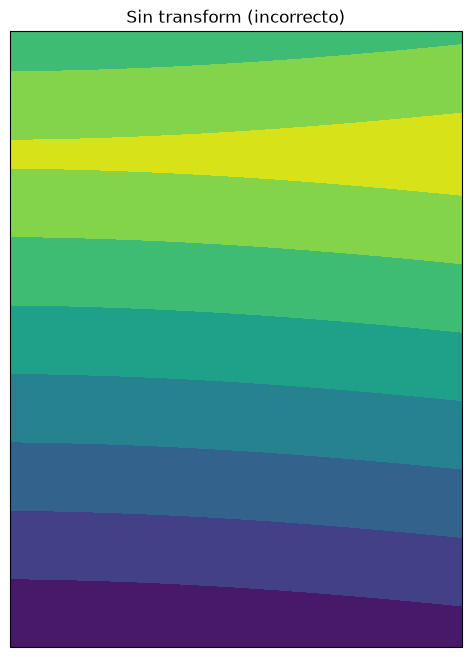

In [18]:
fig, ax = plt.subplots(figsize=(6, 8), subplot_kw={'projection': ccrs.Mercator()})
ax.coastlines()
# 'ax.contourf(x, y, z,...)' rellena el gráfico con color(es); x: coordenadas x, y: coordenadas y, z: valores de cada par ordenado, cmap='a': paleta de colores usado para rellenar el mapa, asigna un color dentro de la paleta a cada valor numérico. La asignación de ax.contourf() a una variable ayuda a usar la propiedad en otras funciones.
im = ax.contourf(lon2d, lat2d, temperatura_sintetica, cmap='viridis')
ax.set_title('Sin transform (incorrecto)')

Nota cómo los datos no calzan con la costa. Ahora agregamos `transform=ccrs.PlateCarree()`, indicando que los datos (`lon2d`, `lat2d`) están en coordenadas geográficas simples:

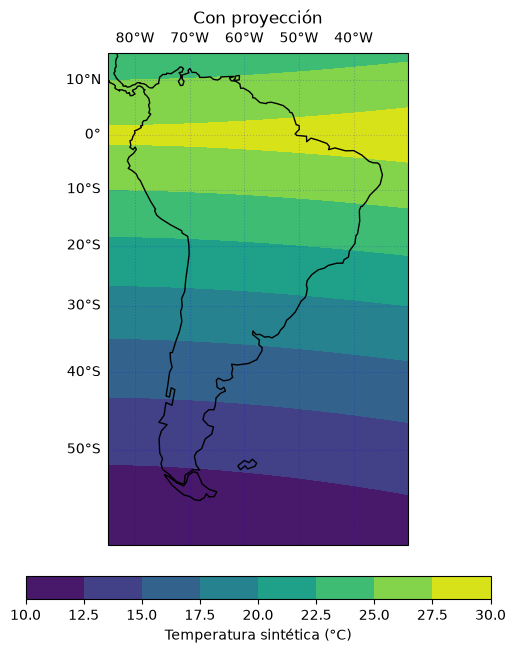

In [19]:
fig, ax = plt.subplots(figsize=(6, 8), subplot_kw={'projection': ccrs.Mercator()})
ax.coastlines()
# Las coordenadas (lon2d, lat2d) se transforman en la asignación de contorno del gráfico
im = ax.contourf(lon2d, lat2d, temperatura_sintetica, cmap='viridis',
                transform=ccrs.PlateCarree())
ax.set_title('Con proyección')

# 'fig.colorbar()' añade una barra de color que indica los valores de la paleta de colores. 'pad=x' indica la distancia de separación entre el gráfico y la barra de color; 'label='x'' asigna un título a la barra de color.
fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, label='Temperatura sintética (°C)')

# Se define las grillas como variable para posterior modificación
gl = ax.gridlines(draw_labels=True, color='b', alpha = 0.2, linestyle=':')

# Se puede eliminar las grillas de lados específicos del gráfico
gl.right_labels = False
gl.bottom_labels = False
#gl.top_labels = False # Genera error en VSCode

## 9. Dato tipo anomalía (colormap divergente)

Ahora un dato sintético que sí tiene un centro con significado: valores positivos y negativos alrededor de cero, como una anomalía climática.

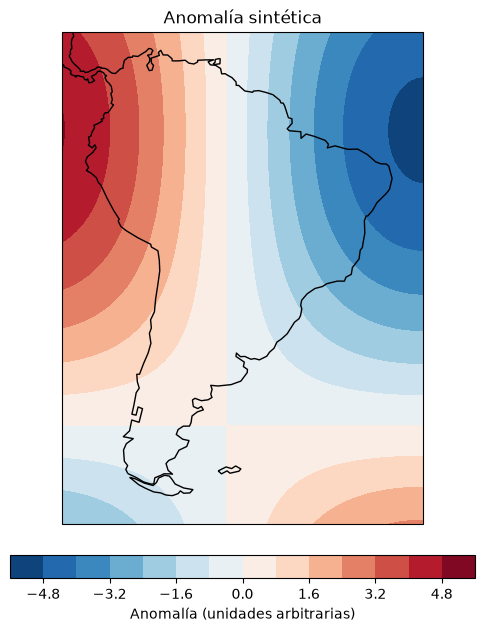

In [20]:
anomalia_sintetica = 5 * np.sin(3 * np.deg2rad(lon2d)) * np.cos(2 * np.deg2rad(lat2d))

fig, ax = plt.subplots(figsize=(6, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.coastlines()
# En 'cmap='x'', añadir '_r' devuelve la paleta de colores inversa. 'levels=x' define el número de particiones del rango de valores de trabajo.
im = ax.contourf(lon2d, lat2d, anomalia_sintetica, cmap='RdBu_r',
                  levels=15, transform=ccrs.PlateCarree())
ax.set_title('Anomalía sintética')
fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, label='Anomalía (unidades arbitrarias)')

`RdBu_r` es un colormap divergente: dos tonos (rojo/azul) que convergen en blanco al centro (cero). No fue necesario centrar el colormap manualmente porque el dato ya está balanceado alrededor de cero; si no lo estuviera, se usaría `TwoSlopeNorm(vcenter=0)` como se vio en la teoría.

### Ejercicio 5

Modifica `anomalia_sintetica` (cambia los coeficientes o las funciones trigonométricas) y observa cómo cambia el patrón. Prueba también cambiar `cmap` por uno secuencial (ej. `viridis`) y compara qué tan bien (o mal) representa el hecho de que hay valores negativos.

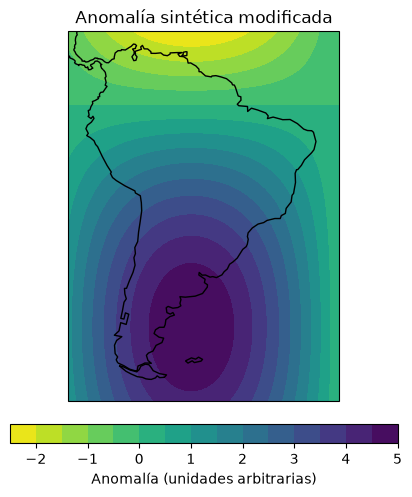

In [21]:
# tu variación de la anomalía aquí
anomalia_sintetica2 = 5 * np.cos(3 * np.deg2rad(lon2d)) * np.sin(2 * np.deg2rad(lat2d))

fig, ax = plt.subplots(figsize=(5,6), subplot_kw={'projection':ccrs.PlateCarree()})
ax.coastlines()

im = ax.contourf(lon2d, lat2d, anomalia_sintetica2, cmap='viridis_r', 
                 levels=15, transform=ccrs.PlateCarree())
ax.set_title('Anomalía sintética modificada')
fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, label='Anomalía (unidades arbitrarias)')

## 10. Dato real: DEM en GeoTIFF

Usemos ahora el archivo real de elevación (SRTM GL3, resolución de 90 m) descargado de OpenTopography.

In [ ]:
import rasterio

# Para evitar errores por el uso de '\' en la dirección de archivo, se coloca 'r' antes de las comillas.
src = rasterio.open(r'C:\Users\sebas\Downloads\ASTGTM_S12W078_dem.tif') # Lectura del archivo

# Variables a usar
data = src.read(1)           # banda 1 como array 2D; asigna los valores en 'data'
bounds = src.bounds          # límites geográficos

# Otras propiedades importantes
transform = src.transform    # georreferenciación
crs = src.crs                # sistema de coordenadas
width, height = src.width, src.height   # dimensiones en píxeles
band_count = src.count   # número de bandas
nodata = src.nodata              # valor que representa "sin dato"
res = src.res                 # resolución espacial (tamaño de píxel)

In [44]:
print('Forma de la data:', data)

print('Georreferenciación:', transform)

print('Sistema de coordenadas:', crs)

print('Límites geográficos:', bounds)

print(width)
print(height)

print('Número de bandas del archivo:', band_count)

print(nodata)

print(res)

Forma de la data: [[   0    0    0 ... 2518 2513 2505]
 [   0    0    0 ... 2539 2533 2523]
 [   0    0    0 ... 2559 2551 2540]
 ...
 [   0    0    0 ...  221  221  221]
 [   0    0    0 ...  220  220  220]
 [   0    0    0 ...  220  220  221]]
Georreferenciación: | 0.00, 0.00,-78.00|
| 0.00,-0.00,-11.00|
| 0.00, 0.00, 1.00|
Sistema de coordenadas: EPSG:4326
Límites geográficos: BoundingBox(left=-78.00013888888888, bottom=-12.000138888888888, right=-76.9998611111111, top=-10.99986111111111)
3601
3601
Número de bandas del archivo: 1
None
(0.0002777777777777778, 0.0002777777777777778)


Con `bounds`, armamos el `extent` para graficar con `imshow`:

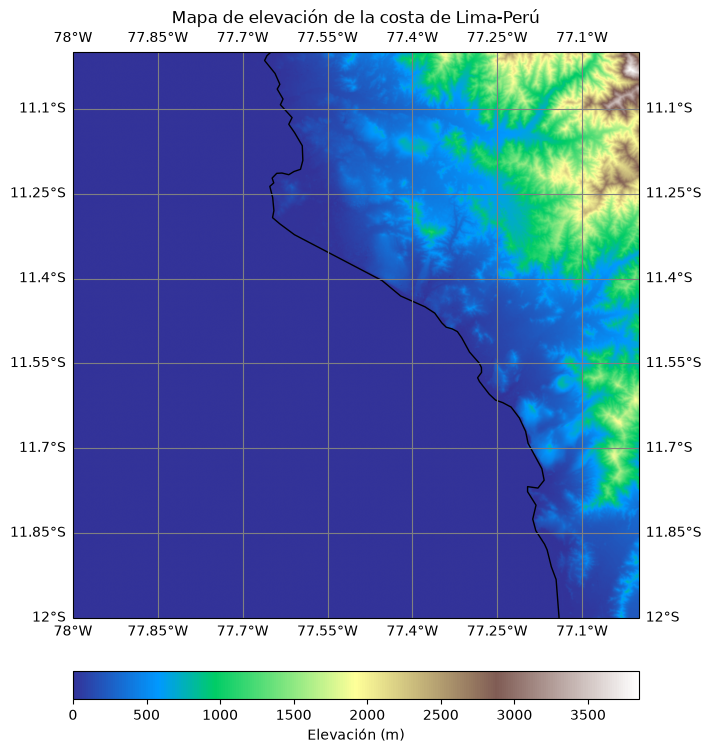

In [ ]:
# bounds.x: Valor georreferencial asignado a la dirección 'x' (ej. left, right, bottom, top)
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

# 'constrained_layout=True' ajusta automáticamente la distribución del gráfico y los elementos para evitar recortes o solapamientos entre sí
fig, ax = plt.subplots(figsize=(7, 8), subplot_kw={'projection': ccrs.PlateCarree()}, constrained_layout=True)

# '.imshow()' muestra la data como imagen ráster. A diferencia de '.cotourf()' (el cual trabaja con datos continuos y genera polígonos vectoriales irregulares), se trabaja con data de píxeles y requiere de una extensión de matriz rectangular regular y uniforme.
# 'origin='x'' define el origen de coordenadas del gráfico para representar los datos de la matriz (ej. upper, lower). Upper: coloca el inicio los datos de la matriz en la esquina superior izquierda. Lower: coloca el inicio de los datos de la matriz en la esquina inferior derecha.
im = ax.imshow(data, extent=extent, origin='upper', cmap='terrain',
                transform=ccrs.PlateCarree()) ## Se puede poner límites de valores para graficar usando vmi y vmax. ej: vmin=1500, vmax=6000
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')

gl = ax.gridlines(draw_labels=True, color='gray')


fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, label='Elevación (m)')
ax.set_title('Mapa de elevación de la costa de Lima-Perú') 
plt.show()

`crs` (el sistema de coordenadas del archivo, `EPSG:4326`) corresponde exactamente a `ccrs.PlateCarree()`, que es lo que usamos en `transform=`.

### Ejercicio 6 (final)

Usando el mismo archivo DEM (u otro que hayas descargado tú de OpenTopography, para una región distinta):

1. Elige una proyección distinta a `PlateCarree` para mostrar el mapa (ej. `Mercator`, `LambertConformal`).
2. Cambia el colormap.
3. Agrega al menos un feature adicional (`BORDERS`, `RIVERS`, etc.).
4. Ajusta el `extent` para enfocarte en una sub-región específica del archivo.



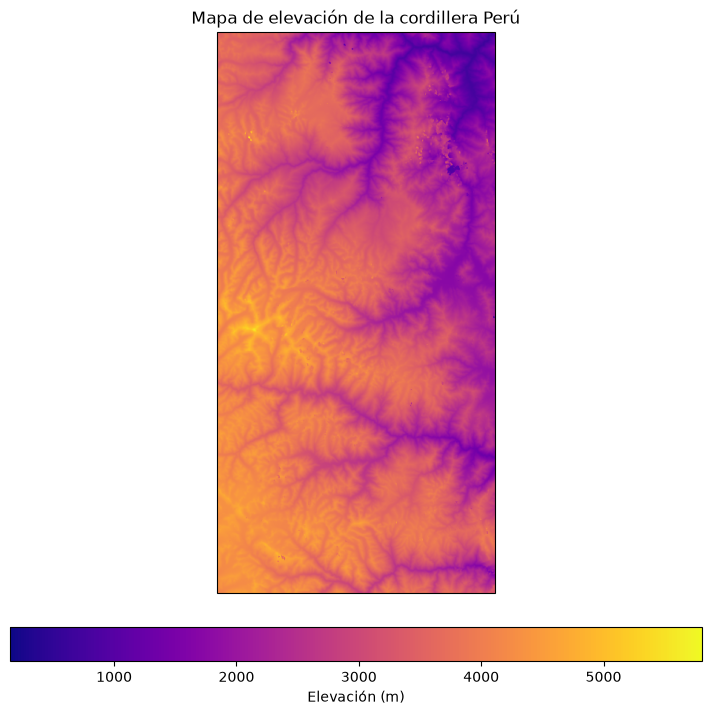

In [96]:
# tu mapa final aquí
# 1. Lectura de datos y asignación de variables
src2 = rasterio.open(r'C:\Users\sebas\Downloads\ASTGTM_S11W076_dem.tif')

data2 = src2.read(1)
bounds2 = src2.bounds

# 2. Creación de mapa
extent2 = [bounds2.left, bounds2.right, bounds2.bottom, bounds2.top]
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': ccrs.Mercator()}, constrained_layout=True)
ax.set_extent(extent2, crs=ccrs.PlateCarree())

im = ax.imshow(data2, extent=extent2, origin='upper', cmap='plasma', transform=ccrs.PlateCarree())

# 3. Agregar subelementos
ax.add_feature(cfeature.RIVERS, alpha=0.5, color='red')

# 4. Enfoque en la zona alta del mapa
ax.set_extent([-76, -75.5, -11, -10], crs=ccrs.PlateCarree())

fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, label='Elevación (m)')
ax.set_title('Mapa de elevación de la cordillera Perú') 
plt.show()

---

## Recursos adicionales

- [Documentación de Cartopy](https://cartopy.readthedocs.io/)
- [Lista de proyecciones](https://cartopy.readthedocs.io/stable/reference/projections.html)
- [Natural Earth Data](https://www.naturalearthdata.com/)
- [OpenTopography](https://portal.opentopography.org/) (fuente del DEM usado en esta práctica)